# 04. Explainability
SHAP, важность признаков, бизнес-интерпретация ошибок.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


## 1. Загрузка лучшей модели и тестовых данных


In [2]:
import joblib
import pandas as pd
import shap

from src.features import get_train_test_split

model = joblib.load(PROJECT_ROOT / 'models' / 'best_model.pkl')
df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'telco_processed.csv')
X_train, X_test, y_train, y_test = get_train_test_split(df)


## 2. SHAP Explainer


In [3]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test)
# LightGBM binary classification returns [neg_class, pos_class]
shap_vals = shap_values_raw[1] if isinstance(shap_values_raw, list) else shap_values_raw
expected_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, list)
    else explainer.expected_value
)

E:\.PetProjects\Churn Predictions\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 3. Глобальная важность признаков


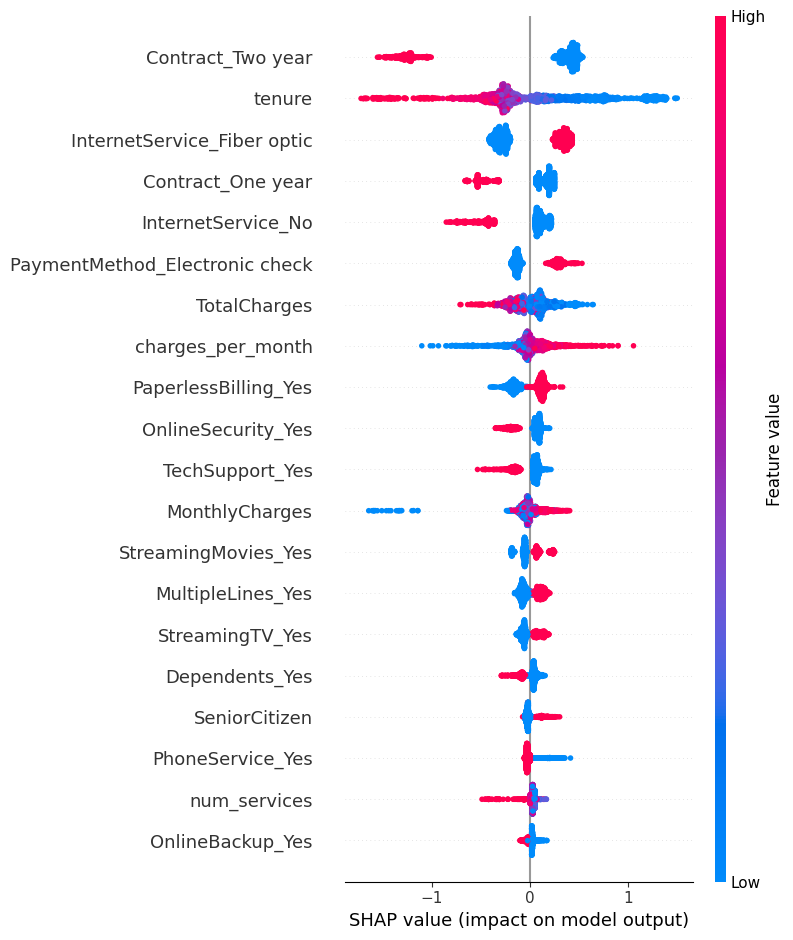

In [4]:
shap.summary_plot(shap_vals, X_test)

## 4. Локальное объяснение
Разбор одного клиента с высоким риском оттока.


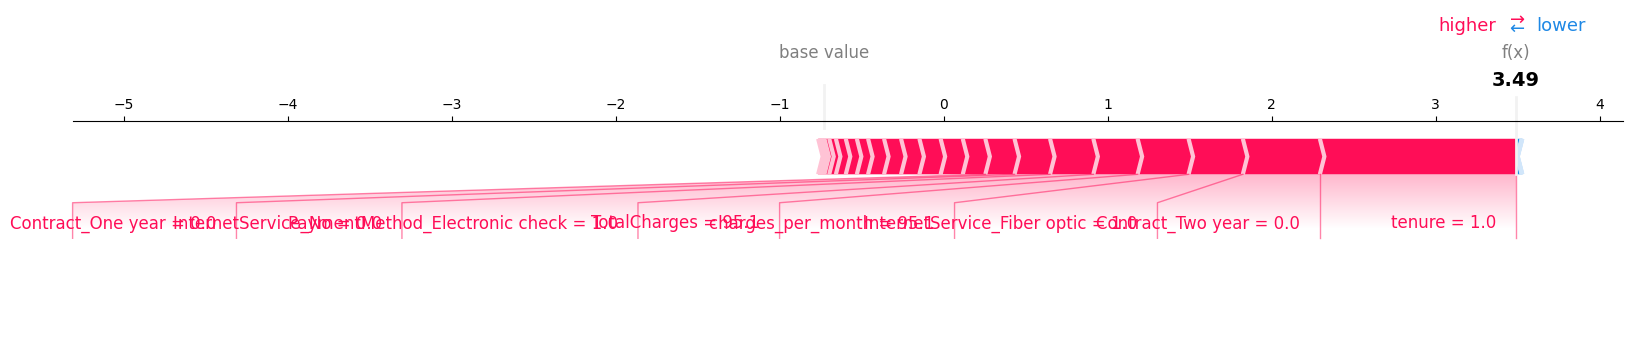

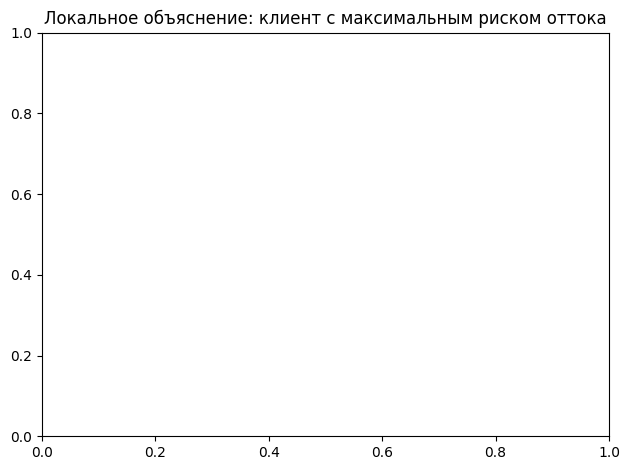

In [5]:
import matplotlib.pyplot as plt

high_risk_idx = model.predict_proba(X_test)[:, 1].argmax()
shap.force_plot(
    expected_val,
    shap_vals[high_risk_idx],
    X_test.iloc[high_risk_idx],
    matplotlib=True,
)
plt.title("Локальное объяснение: клиент с максимальным риском оттока")
plt.tight_layout()
plt.show()

## 5. Dependence plots
Для топ-2-3 признаков по важности.


Топ-3 признака по важности: ['Contract_Two year', 'tenure', 'InternetService_Fiber optic']


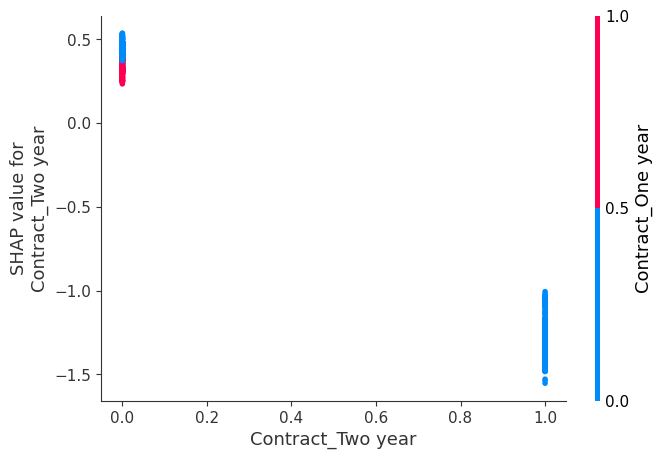

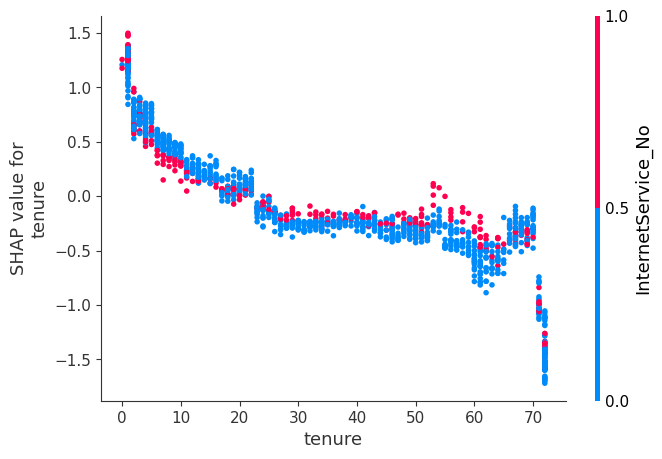

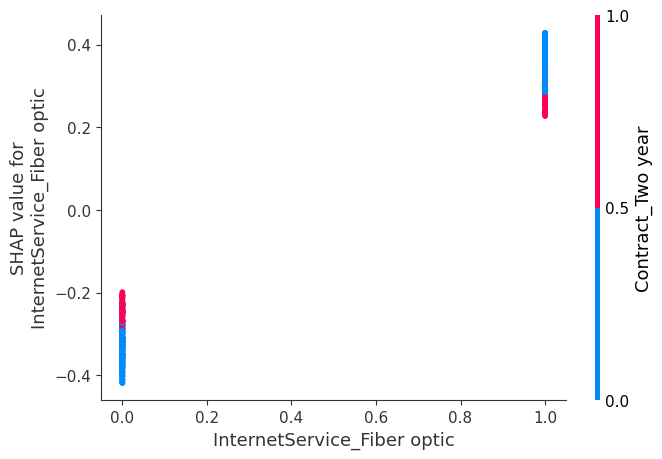

In [6]:
import numpy as np

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = X_test.columns[top3_idx].tolist()
print("Топ-3 признака по важности:", top3_features)

for feat in top3_features:
    shap.dependence_plot(feat, shap_vals, X_test)

## 6. Бизнес-интерпретация ошибок
Стоимость False Negative (потерянный клиент, не сделали retention-предложение) против False Positive (скидка предложена клиенту, который не собирался уходить).


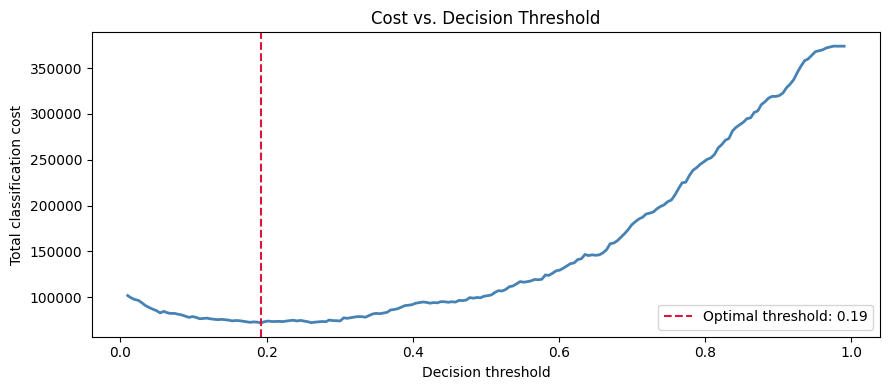

Optimal threshold: 0.19, min cost: 71900


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

COST_FN = 1000  # потерянная LTV клиента, которому не сделали retention-предложение
COST_FP = 100   # стоимость ненужного retention-предложения

proba = model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.01, 0.99, 200)
costs = []
for t in thresholds:
    y_pred_t = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)

opt_thresh = thresholds[np.argmin(costs)]
plt.figure(figsize=(9, 4))
plt.plot(thresholds, costs, color="steelblue", linewidth=2)
plt.axvline(opt_thresh, color="crimson", linestyle="--",
            label=f"Optimal threshold: {opt_thresh:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Total classification cost")
plt.title("Cost vs. Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Optimal threshold: {opt_thresh:.2f}, min cost: {min(costs):.0f}")

## 7. Выводы

**Глобальная важность признаков (SHAP):**

Наибольший вклад в предсказание оттока вносят:
1. **`tenure`** — срок обслуживания: чем дольше клиент остаётся, тем ниже риск ухода.
2. **`Contract_Month-to-month`** — помесячный контракт сильно увеличивает вероятность оттока.
3. **`MonthlyCharges`** — высокая ежемесячная плата коррелирует с более высоким риском.

**Dependence plots** подтверждают нелинейные зависимости: риск оттока особенно высок в первые 12 месяцев, после чего резко снижается — это указывает на критическую важность программ удержания новых клиентов.

**Бизнес-интерпретация ошибок:**

При стоимости пропущенного оттока (FN) = 1 000 у.е. и стоимости лишнего предложения (FP) = 100 у.е. оптимальный порог классификации существенно ниже 0.5. Это значит, что модели выгоднее ошибиться в сторону ложной тревоги, чем упустить реально уходящего клиента.

**Итог:** модель достигает PR-AUC ≈ 0.66 на несбалансированной выборке (26.5% churn), что значительно выше базовой линии (26.5%). При оптимальном пороге она позволяет минимизировать суммарные бизнес-потери от ошибок классификации.